In [1]:
from lcpy.calculators.helpers import ListHolder, ExchangeHolder, ImpactCalculator, ImpactHandler
from lcpy.calculators.bw_int import mpLCAer
import os
from lcpy.hvs.hvs import create_name_dictionaries
from lcpy.hvs.map_dicts import create_mapping, create_list_with_unique_activities

The initial preparation to perfrom easy sensitivity analysis is the same as in the simple LCA and MC_LCA

In [2]:
target_dir = "path_of_directory_where_to_store_results"
os.makedirs(target_dir, exist_ok=True)

In [3]:
brightway_configuration_dictionary = {
    "path_to_brightway_project": "path_to_folder_containing_the_bw_environment_and_packages_installed_there",
    "bw_project": "bw_project_name",
    "bw_database": "bw_project_database_name",
    "bw_biosphere": "bw_project_biosphere_database_name",
    "bw_ecoinvent": "ecoinvent_database_used_name"
}

In [4]:
methods_list = [
('TRACI v2.1', 'acidification', 'acidification potential (AP)'),
('TRACI v2.1', 'climate change', 'global warming potential (GWP100)'),
('TRACI v2.1', 'ecotoxicity: freshwater', 'ecotoxicity: freshwater'),
('TRACI v2.1', 'eutrophication', 'eutrophication potential'),
('TRACI v2.1', 'human toxicity: carcinogenic', 'human toxicity: carcinogenic'),
('TRACI v2.1', 'human toxicity: non-carcinogenic', 'human toxicity: non-carcinogenic'),
('TRACI v2.1', 'ozone depletion', 'ozone depletion potential (ODP)'),
('TRACI v2.1', 'particulate matter formation', 'particulate matter formation potential (PMFP)'),
('TRACI v2.1', 'photochemical oxidant formation', 'maximum incremental reactivity (MIR)'),
]

method_units_list = ['kg SO2-Eq',
 'kg CO2-Eq',
 'CTUe',
 'kg N-Eq',
 'CTUh',
 'CTUh',
 'kg CFC-11-Eq',
 'kg PM2.5-Eq',
 'kg O3-Eq',
]

In [5]:
methods_gp = methods_list[:]
impact_categories_names = ['AP', 'GWP100', 'ECFW', 'EP', 'HTC', 'HTNC', 'ODP', 'PMFP', 'MIR']

In [6]:
impact_categories_units = method_units_list
scenario_names = ['one']

In [7]:
scenarios = 1
timeframe = 1 #operational lifetime after construction
time_step = 1
construction_years = 0

To perform easy sensitivity analysis for the LCA we need to have precalculated the unit impacts for the sub-sub-processes so that we do not need to re-run the bw calculations each time something needs to change. So first we define the dictionaries holding the ecoinvent keys for the sub-processes

In [8]:
keys_nuclear_power_generation = {
'PWR' :  'bw_key_pointing_to_relevant_process',
'BWR' : 'bw_key_pointing_to_relevant_process'
}

keys_fossil_power_generation = {
'NG_ccpp' :  'bw_key_pointing_to_relevant_process',
'NG_convpp' : 'bw_key_pointing_to_relevant_process',
'NG_cogen_conv' :  'bw_key_pointing_to_relevant_process',
'NG_cogen_cc' : 'bw_key_pointing_to_relevant_process',
}

keys_res_power_generation = {
'Hydro' :  'bw_key_pointing_to_relevant_process',
'DGE' : 'bw_key_pointing_to_relevant_process',
'Wind' :  'bw_key_pointing_to_relevant_process',
}

keys_total_power_generation = {
'Nuclear': '',
'Fossil' : '',
'RES' : '',
}

We continue with creating the lists with the keys and calculating the unit impacts for each sub-sub-process

In [9]:
key_list_sub_processes = [keys_nuclear_power_generation, keys_fossil_power_generation, keys_res_power_generation]

In [10]:
mapping_names = create_mapping(keys_total_power_generation, key_list_sub_processes)

In [11]:
unique_activities = create_list_with_unique_activities(key_list_sub_processes)

In [12]:
my_lca = mpLCAer(4, methods_gp, brightway_configuration_dictionary)

In [13]:
my_lca.import_isolated_environment()

In [14]:
my_lca.lca_calculations(mapping_names)

We create the handler and calculator instances

In [15]:
sp_exchange_manager = ExchangeHolder(methods_gp)
sp_impact_calculator = ImpactCalculator()
sp_impact_handler = ImpactHandler(impact_categories_names)

We import pandas and create an empty dataframe

In [16]:
import pandas as pd
df_local_sensitivity = pd.DataFrame(columns= ['Index'] + impact_categories_names)

At this point the sensitivity analysis loop starts. We define an empty list, a name for the sensitivity run, and a parameter to use for changing the parameters of the parametric model according to the sensitivity needs.

The idea is:
We define the baseline parametric scenario for the LCA. We use a sensitivity parameter to change parameters one-at-the-time, and we run the scaling calculations to calculate the impact. Then, the result is stored in a new line in the empty dataframe the name of which line is psecified by the my_index parameter.

The same notebook can be used for scenario analysis when changing only exchange amounts, by using multiple sensitivity parameters, changing the parametric model accordingly and naming the new dataframe row accordingly.

Once the parameters are recalculated the same functions as in the simple LCA are run until the impact of the main process is calculated


In [17]:
sens_param = 1.
my_index = f"Sensitivity_test_{sens_param}%"
rows = []

In [18]:
BWR_capacity = 1500*sens_param
PWR_capacity = 800
NG_ccpp_capacity = 400
NG_convpp_capacity = 750
NG_cogen_conv_capacity = 900
NG_cogen_cc_capacity = 1100
Hydro_pumped_capacity = 420
DGE_capacity = 85
Wind_1_3_capacity = 980
nuclear_capacity = BWR_capacity + PWR_capacity
ng_capacity = NG_ccpp_capacity + NG_convpp_capacity + NG_cogen_conv_capacity + NG_cogen_cc_capacity
res_capacity = Hydro_pumped_capacity + DGE_capacity + Wind_1_3_capacity
total_capacity = nuclear_capacity + ng_capacity + res_capacity

In [19]:
nuclear_exchanges_amounts = [
PWR_capacity/nuclear_capacity,
BWR_capacity/nuclear_capacity
]

fossil_exchanges_amounts = [
NG_ccpp_capacity/ng_capacity,
NG_convpp_capacity/ng_capacity,
NG_cogen_conv_capacity/ng_capacity,
NG_cogen_cc_capacity/ng_capacity,
]

res_exchanges_amounts = [
Hydro_pumped_capacity/res_capacity,
DGE_capacity/res_capacity,
Wind_1_3_capacity/res_capacity,
]

mp_exchanges_amounts = [
nuclear_capacity/total_capacity,
ng_capacity/total_capacity,
res_capacity/total_capacity,
]

In [20]:
exchanges_list_sp = [nuclear_exchanges_amounts, fossil_exchanges_amounts, res_exchanges_amounts]

In [21]:
mapping_exchanges = create_mapping(keys_total_power_generation, exchanges_list_sp)

In [22]:
sp_exchange_manager.create_exchange_arrays(mapping_exchanges)

In [23]:
sp_impact_calculator.impact_calculation_simple(my_lca.unit_impacts, sp_exchange_manager.exchanges_dict)

In [24]:
names_dictionary = create_name_dictionaries(mapping_names, key_list_sub_processes)

In [25]:
sp_impact_handler.create_dataframes(sp_impact_calculator.simple_impacts, names_dictionary)

In [26]:
total_impact_handler = ImpactHandler(impact_categories_names)

In [27]:
list_with_names_of_main_processes = ['Electricity production']

In [28]:
total_impact_handler.calculate_total_unit_impact(sp_impact_handler.total_impact_arrays, list_with_names_of_main_processes[0])

In [29]:
total_exchange_handler = ExchangeHolder(methods_gp)
total_impact_calculator = ImpactCalculator()

In [30]:
names_dictionary_main_process = {list_with_names_of_main_processes[0]: list(names_dictionary.keys()) }

In [31]:
mapping_exchanges_main_process = {list_with_names_of_main_processes[0]: mp_exchanges_amounts}

In [32]:
total_exchange_handler.create_exchange_arrays(mapping_exchanges_main_process)
total_impact_calculator.impact_calculation_simple(total_impact_handler.total_unit_impact, total_exchange_handler.exchanges_dict)

We have now calculated the new results considering the introduced sensitivity. The below lines of code extract the impacts for each category from the attribute and
put them as a new line in the empty dataframe with index that set at the start of the sensitivity loop.

Once that is appended in the dataframe, the dataframe can be saved, or used for visualization, or we can go up change the sensitivity parameter and recalculate and input again in the dataframe

In [33]:
number_cat = total_impact_calculator.simple_impacts[list_with_names_of_main_processes[0]].shape[1]
temp = [0 for n in range(number_cat)]
for i in range(number_cat):
    temp[i] = total_impact_calculator.simple_impacts[list_with_names_of_main_processes[0]][:, i].sum()

row_data = dict(zip(impact_categories_names, temp))
row_data["Index"] = my_index
rows.append(row_data)
df_local_sensitivity = pd.concat([df_local_sensitivity, pd.DataFrame(rows)], ignore_index=True)

C:\Users\sgkousis\AppData\Local\Temp\ipykernel_5236\566339005.py:9: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_local_sensitivity = pd.concat([df_local_sensitivity, pd.DataFrame(rows)], ignore_index=True)


In [34]:
df_local_sensitivity.to_excel("data_sensitivity_analysis.xlsx", index=True, engine='openpyxl')

And below we present a funciton that can use this dataframe to plot a tornado plot, in case the sensitivities are plus minus X%.

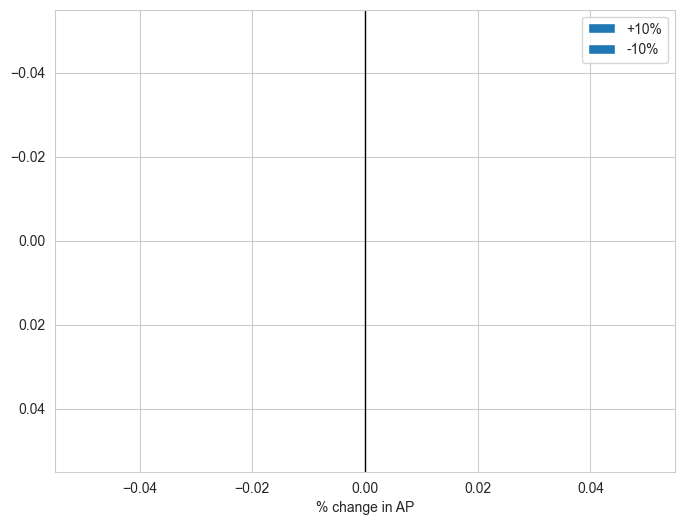

In [35]:
import numpy as np
import matplotlib.pyplot as plt

parameters = df_local_sensitivity.iloc[::3, 0].values
num_params = len(parameters)

baseline = df_local_sensitivity['GWP100'].iloc[::3].values  # Baseline values
minus_10 = df_local_sensitivity['GWP100'].iloc[1::3].values  # -10% values
plus_10 = df_local_sensitivity['GWP100'].iloc[2::3].values  # +10% values

deviation_minus = (minus_10 - baseline) / baseline * 100
deviation_plus = (plus_10 - baseline) / baseline * 100

sorted_indices = np.argsort(abs(deviation_plus - deviation_minus))[::-1]
sorted_params = [parameters[i] for i in sorted_indices]
sorted_dev_minus = deviation_minus[sorted_indices]
sorted_dev_plus = deviation_plus[sorted_indices]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(sorted_params, sorted_dev_plus, color='green', label='+10%')
ax.barh(sorted_params, sorted_dev_minus, color='red', label='-10%')

ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel("% change in " + 'AP')
ax.legend()
plt.gca().invert_yaxis()  # Reverse order for readability
plt.show()